In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/cleaned/final_analysis_data.csv")

In [4]:
data['treatment_year'].value_counts().sort_index()

treatment_year
2000.0     24
2005.0    552
2008.0     24
2010.0     48
2012.0     48
2013.0     24
2015.0     24
2016.0     24
2017.0     48
2018.0     24
2019.0     48
2020.0     48
2022.0     48
Name: count, dtype: int64

In [5]:
data['years_relative_to_treatment'].describe()

count    984.000000
mean      -1.890244
std        9.268250
min      -26.000000
25%       -8.000000
50%       -2.000000
75%        5.000000
max       19.000000
Name: years_relative_to_treatment, dtype: float64

In [6]:
# Check which countries adopted in 2005
eu_2005_candidates = data[data['treatment_year'] == 2005]['country'].unique()
print("Potential EU 2005 adopters:", eu_2005_candidates)
print("Number of countries:", len(eu_2005_candidates))

# Check if these look like EU countries to you
for country in eu_2005_candidates:
    print(f"{country}: {len(data[data['country'] == country])} observations")

Potential EU 2005 adopters: ['Austria' 'Belgium' 'Bulgaria' 'Croatia' 'Cyprus' 'Denmark' 'Estonia'
 'France' 'Germany' 'Greece' 'Hungary' 'Ireland' 'Italy' 'Latvia'
 'Lithuania' 'Luxembourg' 'Malta' 'Netherlands' 'Portugal' 'Romania'
 'Slovakia' 'Slovenia' 'Spain']
Number of countries: 23
Austria: 24 observations
Belgium: 24 observations
Bulgaria: 24 observations
Croatia: 24 observations
Cyprus: 24 observations
Denmark: 24 observations
Estonia: 24 observations
France: 24 observations
Germany: 24 observations
Greece: 24 observations
Hungary: 24 observations
Ireland: 24 observations
Italy: 24 observations
Latvia: 24 observations
Lithuania: 24 observations
Luxembourg: 24 observations
Malta: 24 observations
Netherlands: 24 observations
Portugal: 24 observations
Romania: 24 observations
Slovakia: 24 observations
Slovenia: 24 observations
Spain: 24 observations


In [9]:
# Create grouping 
eu_2005_countries = ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 
                     'Denmark', 'Estonia', 'France', 'Germany', 'Greece', 
                     'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 
                     'Luxembourg', 'Malta', 'Netherlands', 'Portugal', 
                     'Romania', 'Slovakia', 'Slovenia', 'Spain']


def create_clean_treatment_groups(data):
    non_eu_early = data[(data['treatment_year'] <= 2005) & 
                       (~data['country'].isin(eu_2005_countries))]
     
    eu_bloc = data[data['country'].isin(eu_2005_countries)]
    
    # Non-EU later adopters
    non_eu_late = data[(data['treatment_year'] > 2005) & 
                      (~data['country'].isin(eu_2005_countries))]
    
    # Never treated
    never_treated = data[data['treatment_year'].isna()]
    
    return non_eu_early, eu_bloc, non_eu_late, never_treated

# Apply the function
non_eu_early, eu_bloc, non_eu_late, never_treated = create_clean_treatment_groups(data)

# Check your new groups
print("Clean Treatment Groups:")
print(f"Non-EU Early: {len(non_eu_early)} obs, Countries: {non_eu_early['country'].unique()}")
print(f"EU Bloc 2005: {len(eu_bloc)} obs, Countries: {len(eu_bloc['country'].unique())} countries")  
print(f"Non-EU Late: {len(non_eu_late)} obs, Countries: {non_eu_late['country'].unique()}")
print(f"Never Treated: {len(never_treated)} obs, Countries: {len(never_treated['country'].unique())} countries")

Clean Treatment Groups:
Non-EU Early: 24 obs, Countries: ['Finland']
EU Bloc 2005: 552 obs, Countries: 23 countries
Non-EU Late: 408 obs, Countries: ['Argentina' 'Australia' 'Canada' 'Chile' 'China' 'Colombia' 'Iceland'
 'Japan' 'Kazakhstan' 'Mexico' 'New Zealand' 'Singapore' 'South Africa'
 'Switzerland' 'Ukraine' 'United Kingdom' 'Uruguay']
Never Treated: 2908 obs, Countries: 122 countries


In [10]:
# Create grouping 
eu_2005_countries = ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 
                     'Denmark', 'Estonia', 'France', 'Germany', 'Greece', 
                     'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 
                     'Luxembourg', 'Malta', 'Netherlands', 'Portugal', 
                     'Romania', 'Slovakia', 'Slovenia', 'Spain']


def create_adoption_wave_groups(data):
    # Wave 1: Early pioneers (2000-2005, including Finland + EU)
    wave1_early = data[data['treatment_year'] <= 2005]
    
    # Wave 2: Mid-period adopters (2008-2012)  
    wave2_mid = data[(data['treatment_year'] > 2005) & (data['treatment_year'] <= 2012)]
    
    # Wave 3: Recent adopters (2013+)
    wave3_late = data[data['treatment_year'] > 2012]
    
    # Never treated
    never_treated = data[data['treatment_year'].isna()]
    
    return wave1_early, wave2_mid, wave3_late, never_treated


wave1, wave2, wave3, never_treated = create_adoption_wave_groups(data)

print("Adoption Wave Groups:")
print(f"Wave 1 (2000-2005): {len(wave1)} obs")
print(f"  Countries: {wave1['country'].unique()}")
print(f"Wave 2 (2008-2012): {len(wave2)} obs") 
print(f"  Countries: {wave2['country'].unique()}")
print(f"Wave 3 (2013+): {len(wave3)} obs")
print(f"  Countries: {wave3['country'].unique()}")
print(f"Never Treated: {len(never_treated)} obs")

Adoption Wave Groups:
Wave 1 (2000-2005): 576 obs
  Countries: ['Austria' 'Belgium' 'Bulgaria' 'Croatia' 'Cyprus' 'Denmark' 'Estonia'
 'Finland' 'France' 'Germany' 'Greece' 'Hungary' 'Ireland' 'Italy'
 'Latvia' 'Lithuania' 'Luxembourg' 'Malta' 'Netherlands' 'Portugal'
 'Romania' 'Slovakia' 'Slovenia' 'Spain']
Wave 2 (2008-2012): 120 obs
  Countries: ['Australia' 'Iceland' 'Japan' 'New Zealand' 'Switzerland']
Wave 3 (2013+): 288 obs
  Countries: ['Argentina' 'Canada' 'Chile' 'China' 'Colombia' 'Kazakhstan' 'Mexico'
 'Singapore' 'South Africa' 'Ukraine' 'United Kingdom' 'Uruguay']
Never Treated: 2908 obs


In [11]:
# Spec B: EU + Non-EU Late + Never treated -> Focus on coordinated implementation (EU)
spec_b_sample = pd.concat([
    eu_bloc,
    non_eu_late,
    never_treated
])

In [12]:
def create_treatment_indicators(df):
    df = df.copy()
    
    # Create treatment group variable
    df['treatment_group'] = 'Never Treated'
    df.loc[df['country'].isin(eu_2005_countries), 'treatment_group'] = 'EU 2005'
    df.loc[df['treatment_year'] > 2005, 'treatment_group'] = 'Non-EU Late'
    
    return df

In [13]:
spec_b_sample = create_treatment_indicators(spec_b_sample)

In [16]:
def get_pretreatment_data(df):
    eu_pre = df[(df['treatment_group'] == 'EU 2005') & (df['year'] < 2005)]
    
    non_eu_pre = df[(df['treatment_group'] == 'Non-EU Late') & 
                    (df['years_relative_to_treatment'] < 0)]
    
    never_pre = df[(df['treatment_group'] == 'Never Treated') & 
                   (df['year'] >= 1996) & (df['year'] <= 2004)]
    
    return eu_pre, non_eu_pre, never_pre

In [17]:
eu_pre, non_eu_pre, never_pre = get_pretreatment_data(spec_b_sample)

In [18]:
print("Pre-treatment data availability:")
print(f"EU pre-2005: {len(eu_pre)} observations")
print(f"Non-EU late pre-treatment: {len(non_eu_pre)} observations") 
print(f"Never treated (1996-2004): {len(never_pre)} observations")

# Check year coverage
print(f"\nEU pre-treatment years: {sorted(eu_pre['year'].unique())}")
print(f"Non-EU pre-treatment years: {sorted(non_eu_pre['year'].unique())}")
print(f"Never treated years: {sorted(never_pre['year'].unique())}")

Pre-treatment data availability:
EU pre-2005: 207 observations
Non-EU late pre-treatment: 334 observations
Never treated (1996-2004): 1080 observations

EU pre-treatment years: [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004]
Non-EU pre-treatment years: [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
Never treated years: [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004]


In [23]:
def calculate_group_means(df):
    group_means = df.groupby(["treatment_group", "year"]).agg({
        'co2_per_capita' : 'mean',
        'co2_per_capita_future_trend': 'mean',
        'gdp': 'mean',
        'population' : 'count'
    }).round(4)

    return group_means

In [24]:
pretreatment_sample = pd.concat([eu_pre, non_eu_pre, never_pre])
group_means = calculate_group_means(pretreatment_sample)
print(group_means)

                      co2_per_capita  co2_per_capita_future_trend  \
treatment_group year                                                
EU 2005         1996          8.6847                      -0.1442   
                1997          8.4810                      -0.0820   
                1998          8.3634                       0.0424   
                1999          8.2520                       0.0948   
                2000          8.2351                       0.1876   
                2001          8.4907                       0.1320   
                2002          8.5363                       0.1156   
                2003          8.7978                       0.0118   
                2004          8.8867                      -0.0209   
Never Treated   1996          3.6733                      -0.0173   
                1997          3.7482                       0.0151   
                1998          3.6509                       0.0528   
                1999          3.62

In [26]:
def create_parallel_trends_data(df):
    pt_data = df.groupby(['treatment_group', 'year']).agg({
        'co2_per_capita': 'mean',
        'co2_per_capita_future_trend': 'mean',
        'country': 'count'  # Number of countries in each group-year
    }).reset_index()
    
    pt_data = pt_data.rename(columns={
        'co2_per_capita': 'avg_co2_per_capita',
        'co2_per_capita_future_trend': 'avg_future_trend', 
        'country': 'n_countries'
    })
    
    return pt_data

In [30]:
pt_data = create_parallel_trends_data(pretreatment_sample)
pt_data.head(10)

,treatment_group,year,avg_co2_per_capita,avg_future_trend,n_countries
0,EU 2005,1996,8.684652,-0.144217,23
1,EU 2005,1997,8.481043,-0.081986,23
2,EU 2005,1998,8.363391,0.042435,23
3,EU 2005,1999,8.252000,0.094754,23
4,EU 2005,2000,8.235087,0.187565,23
5,EU 2005,2001,8.490696,0.132015,23
6,EU 2005,2002,8.536261,0.115565,23
7,EU 2005,2003,8.797783,0.011754,23
8,EU 2005,2004,8.886739,-0.020870,23
9,Never Treated,1996,3.673333,-0.017275,120


In [35]:
def plot_parallel_trends(pt_data):
    years_by_group = pt_data.groupby('treatment_group')['year'].apply(list)
    print("Years available by group:")
    for group, years in years_by_group.items():
        print(f"{group}: {min(years)}-{max(years)}")
        
    plt.figure(figsize=(12, 6))

    for group in pt_data['treatment_group'].unique():
        group_data = pt_data[pt_data['treatment_group'] == group]
        plt.plot(group_data['year'], group_data['avg_future_trend'], 
                marker='o', linewidth=2, label=group)

    plt.xlabel('Year')
    plt.ylabel('Average CO2 per Capita (tonnes)')
    plt.title('Parallel Trends Test: Pre-Treatment CO2 Emissions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Years available by group:
EU 2005: 1996-2004
Never Treated: 1996-2004
Non-EU Late: 1996-2019


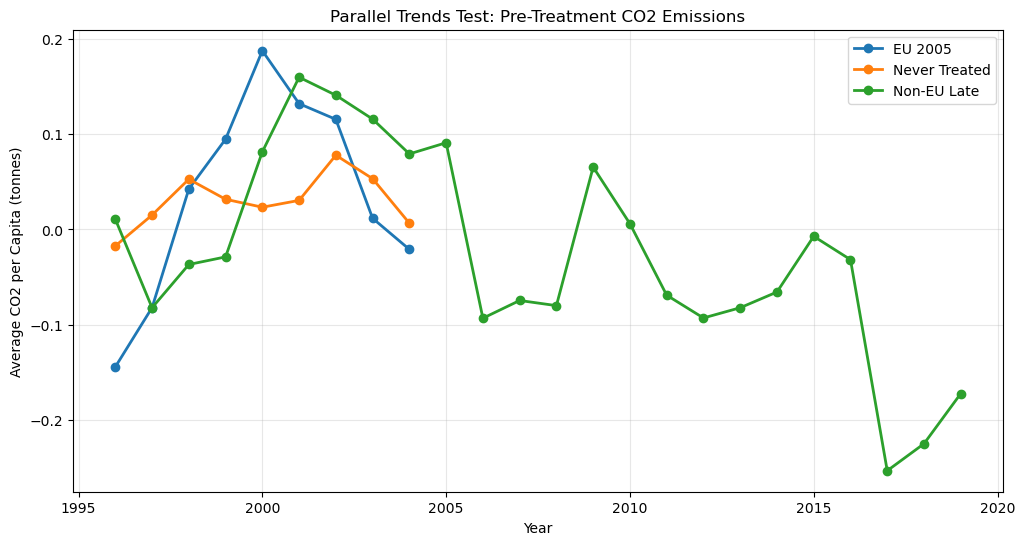

In [36]:
plot_parallel_trends(pt_data)

In [38]:
import statsmodels.formula.api as smf
pre_trend_test = smf.ols('''
co2_per_capita_future_trend ~ year*C(treatment_group) + 
log_gdp + log_population
''', data=pretreatment_sample).fit()

print("Parallel trends test (interaction coefficients):")
print(pre_trend_test.summary().tables[1])

Parallel trends test (interaction coefficients):
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                  -31.4806     18.261     -1.724      0.085     -67.299       4.338
C(treatment_group)[T.Never Treated]         23.1555     19.925      1.162      0.245     -15.926      62.237
C(treatment_group)[T.Non-EU Late]           46.0836     19.201      2.400      0.017       8.423      83.744
year                                         0.0157      0.009      1.724      0.085      -0.002       0.034
year:C(treatment_group)[T.Never Treated]    -0.0116      0.010     -1.162      0.245      -0.031       0.008
year:C(treatment_group)[T.Non-EU Late]      -0.0230      0.010     -2.401      0.016      -0.042      -0.004
log_gdp                                      0.0059      0.009      0.665      

In [39]:
# Restrict all groups to same pre-treatment period: 1996-2004
def create_fair_pretreatment_sample(df):
    # Common pre-treatment window for all groups
    common_pretreatment = df[(df['year'] >= 1996) & (df['year'] <= 2004)]
    
    # Filter by treatment groups
    eu_pre_fair = common_pretreatment[common_pretreatment['treatment_group'] == 'EU 2005']
    noneu_pre_fair = common_pretreatment[common_pretreatment['treatment_group'] == 'Non-EU Late'] 
    never_pre_fair = common_pretreatment[common_pretreatment['treatment_group'] == 'Never Treated']
    
    return eu_pre_fair, noneu_pre_fair, never_pre_fair


eu_pre_fair, noneu_pre_fair, never_pre_fair = create_fair_pretreatment_sample(spec_b_sample)

print("Fair pre-treatment sample (1996-2004 only):")
print(f"EU pre-treatment: {len(eu_pre_fair)} obs")
print(f"Non-EU pre-treatment: {len(noneu_pre_fair)} obs") 
print(f"Never treated: {len(never_pre_fair)} obs")


fair_pretreatment_sample = pd.concat([eu_pre_fair, noneu_pre_fair, never_pre_fair])

Fair pre-treatment sample (1996-2004 only):
EU pre-treatment: 207 obs
Non-EU pre-treatment: 153 obs
Never treated: 1080 obs


In [40]:
pre_trend_test_fair = smf.ols('''
co2_per_capita_future_trend ~ year*C(treatment_group) + 
log_gdp + log_population
''', data=fair_pretreatment_sample).fit()

print("Fair parallel trends test (1996-2004):")
print(pre_trend_test_fair.summary().tables[1])

Fair parallel trends test (1996-2004):
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                  -31.1704     18.772     -1.660      0.097     -67.995       5.654
C(treatment_group)[T.Never Treated]         23.0411     20.483      1.125      0.261     -17.138      63.220
C(treatment_group)[T.Non-EU Late]          -15.3794     28.781     -0.534      0.593     -71.837      41.078
year                                         0.0156      0.009      1.660      0.097      -0.003       0.034
year:C(treatment_group)[T.Never Treated]    -0.0115      0.010     -1.124      0.261      -0.032       0.009
year:C(treatment_group)[T.Non-EU Late]       0.0077      0.014      0.535      0.593      -0.021       0.036
log_gdp                                      0.0102      0.009      1.096      0.273     

In [43]:
clean_sample = spec_b_sample[
    (spec_b_sample['year'] >= 1996) & 
    (spec_b_sample['treatment_group'].isin(['EU 2005', 'Non-EU Late', 'Never Treated']))
]

In [95]:
clean_sample.to_csv("../data/cleaned/treatment_sample.csv")

In [45]:
basic_did = smf.ols('''
co2_per_capita_future_trend ~ post_carbon_tax
''', data=clean_sample).fit()

print("Basic DiD (no controls):")
print(basic_did.summary().tables[1])

Basic DiD (no controls):
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0036      0.006      0.612      0.540      -0.008       0.015
post_carbon_tax    -0.1816      0.017    -10.867      0.000      -0.214      -0.149


In [49]:
# Check the distribution of your outcome variable
print("Distribution of co2_per_capita_future_trend:")
print(clean_sample['co2_per_capita_future_trend'].describe())

# Calculate effect size
mean_trend = clean_sample['co2_per_capita_future_trend'].mean()
treatment_effect = -0.1816
effect_size = abs(treatment_effect) / abs(mean_trend) if mean_trend != 0 else "Cannot calculate"

print(f"\nMean emission trend: {mean_trend:.4f}")
print(f"Treatment effect: {treatment_effect:.4f}")
print(f"Effect size (% of mean): {effect_size:.1%}" if isinstance(effect_size, float) else effect_size)

Distribution of co2_per_capita_future_trend:
count    3868.000000
mean       -0.019409
std         0.351237
min        -6.755333
25%        -0.060667
50%         0.004333
75%         0.050333
max         3.382333
Name: co2_per_capita_future_trend, dtype: float64

Mean emission trend: -0.0194
Treatment effect: -0.1816
Effect size (% of mean): 935.6%


In [51]:
# DiD with fixed effects
did_with_fe = smf.ols('''
co2_per_capita_future_trend ~ post_carbon_tax + C(year) + C(country)
''', data=clean_sample).fit()

print("DiD with Fixed Effects:")
print(did_with_fe.summary().tables[1])

DiD with Fixed Effects:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -0.0220      0.070     -0.314      0.754      -0.159       0.115
C(year)[T.1997]                                0.0234      0.036      0.652      0.514      -0.047       0.094
C(year)[T.1998]                                0.0743      0.036      2.075      0.038       0.004       0.145
C(year)[T.1999]                                0.0669      0.036      1.867      0.062      -0.003       0.137
C(year)[T.2000]                                0.0857      0.036      2.392      0.017       0.015       0.156
C(year)[T.2001]                                0.0914      0.036      2.551      0.011       0.021       0.162
C(year)[T.2002]                                0.1226      0.036      3.421      0.001  

In [52]:
# DiD with economic controls
did_with_economic_control = smf.ols('''
co2_per_capita_future_trend ~ post_carbon_tax + C(year) + C(country) + log_gdp
+ log_population + nuclear_pct + fossil_pct + renewable_pct + industry_share_gdp + energy_per_capita
''', data=clean_sample).fit()

print("DiD with Economic Controls:")
print(did_with_economic_control.summary().tables[1])

DiD with Economic Controls:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -2.8405      0.991     -2.866      0.004      -4.784      -0.897
C(year)[T.1997]                                0.0208      0.035      0.601      0.548      -0.047       0.089
C(year)[T.1998]                                0.0691      0.035      1.987      0.047       0.001       0.137
C(year)[T.1999]                                0.0564      0.035      1.619      0.106      -0.012       0.125
C(year)[T.2000]                                0.0747      0.035      2.135      0.033       0.006       0.143
C(year)[T.2001]                                0.0771      0.035      2.187      0.029       0.008       0.146
C(year)[T.2002]                                0.1065      0.036      2.999      0.0

In [63]:
# Create sample with no imputed data
no_imputation_sample = clean_sample[
    (clean_sample['nuclear_pct_filled'] == 0) & 
    (clean_sample['fossil_pct_filled'] == 0) & 
    (clean_sample['renewable_pct_filled'] == 0) &
    (clean_sample['industry_share_gdp_extrapolated'] == 0)
]

print("Sample sizes:")
print(f"Full sample: {len(clean_sample)}")
print(f"No imputation: {len(no_imputation_sample)}")

# Run DiD on clean data only
did_no_imputation = smf.ols('''
co2_per_capita_future_trend ~ post_carbon_tax + 
log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct + industry_share_gdp +
C(year) + C(country)
''', data=no_imputation_sample).fit()

print("DiD coefficient comparison:")
print(f"Full sample: {did_with_economic_control.params['post_carbon_tax']:.4f}")
print(f"No imputation: {did_no_imputation.params['post_carbon_tax']:.4f}")

Sample sizes:
Full sample: 3868
No imputation: 3232
DiD coefficient comparison:
Full sample: -0.1640
No imputation: -0.1552


In [64]:
print("DiD with Economic Controls - No Imputation:")
print(did_no_imputation.summary().tables[1])

DiD with Economic Controls - No Imputation:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -0.6702      1.080     -0.620      0.535      -2.788       1.448
C(year)[T.1997]                                0.0626      0.036      1.721      0.085      -0.009       0.134
C(year)[T.1998]                                0.0770      0.037      2.109      0.035       0.005       0.149
C(year)[T.1999]                                0.0711      0.037      1.945      0.052      -0.001       0.143
C(year)[T.2000]                                0.1017      0.037      2.779      0.005       0.030       0.173
C(year)[T.2001]                                0.1169      0.037      3.172      0.002       0.045       0.189
C(year)[T.2002]                                0.1314      0.037    

In [70]:
# DiD with governance controls
did_with_governance_control = smf.ols('''
co2_per_capita_future_trend ~ post_carbon_tax + post_carbon_tax*governance_pc1 + post_carbon_tax*governance_pc2 + log_gdp
+ log_population + nuclear_pct + fossil_pct + renewable_pct + industry_share_gdp + energy_per_capita + 
C(year) + C(country) 
''', data=clean_sample).fit()

print("DiD with Governance Controls:")
print(did_with_governance_control.summary().tables[1])

DiD with Governance Controls:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -2.9938      0.997     -3.004      0.003      -4.948      -1.040
C(year)[T.1997]                                0.0222      0.035      0.637      0.524      -0.046       0.091
C(year)[T.1998]                                0.0716      0.035      2.049      0.041       0.003       0.140
C(year)[T.1999]                                0.0599      0.035      1.709      0.088      -0.009       0.129
C(year)[T.2000]                                0.0790      0.035      2.243      0.025       0.010       0.148
C(year)[T.2001]                                0.0813      0.035      2.296      0.022       0.012       0.151
C(year)[T.2002]                                0.1116      0.036      3.127      0

In [69]:
corr_check = clean_sample[['post_carbon_tax', 'governance_pc1', 'governance_pc2']].corr()
print(corr_check)

                 post_carbon_tax  governance_pc1  governance_pc2
post_carbon_tax         1.000000        0.488070       -0.080885
governance_pc1          0.488070        1.000000        0.002109
governance_pc2         -0.080885        0.002109        1.000000


In [82]:
# DiD with continuous tax rates
did_with_continuous = smf.ols('''
co2_per_capita_future_trend ~ tax_price + 
tax_price*governance_pc1 + 
tax_price*governance_pc2 + 
log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct +
industry_share_gdp + energy_per_capita + 
C(year) + C(country) 
''', data=clean_sample).fit()

print("DiD with Continuous Treatment:")
print(did_with_continuous.summary().tables[1])

DiD with Continuous Treatment:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -3.7208      0.981     -3.791      0.000      -5.645      -1.797
C(year)[T.1997]                                0.0202      0.035      0.576      0.565      -0.048       0.089
C(year)[T.1998]                                0.0683      0.035      1.944      0.052      -0.001       0.137
C(year)[T.1999]                                0.0548      0.035      1.557      0.119      -0.014       0.124
C(year)[T.2000]                                0.0719      0.035      2.033      0.042       0.003       0.141
C(year)[T.2001]                                0.0730      0.036      2.054      0.040       0.003       0.143
C(year)[T.2002]                                0.1023      0.036      2.856      

In [72]:
# Check tax rate distribution
print("Tax rate distribution:")
print(clean_sample[clean_sample['tax_price'] > 0]['tax_price'].describe())

# Check if most tax rates are low
print("\nTax rate bins:")
print(pd.cut(clean_sample[clean_sample['tax_price'] > 0]['tax_price'], 
            bins=[0, 10, 30, 50, 100, 200]).value_counts())

Tax rate distribution:
count    484.000000
mean      24.835997
std       29.846260
min        0.012692
25%        6.757100
50%       17.265976
75%       26.288971
max      168.825742
Name: tax_price, dtype: float64

Tax rate bins:
tax_price
(10, 30]      189
(0, 10]       183
(30, 50]       60
(50, 100]      32
(100, 200]     20
Name: count, dtype: int64


In [75]:
# Maybe effect builds over time?
did_time_varying = smf.ols('''
co2_per_capita_future_trend ~ tax_price + years_since_tax +
tax_price*years_since_tax + 
tax_price*governance_pc1 + tax_price*governance_pc2 + 
log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct +
industry_share_gdp + energy_per_capita + 
C(year) + C(country) 
''', data=clean_sample).fit()

print("DiD with Continuous Treatment + years since tax:")
print(did_with_continuous.summary().tables[1])

DiD with Continuous Treatment + years since tax:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -3.7208      0.981     -3.791      0.000      -5.645      -1.797
C(year)[T.1997]                                0.0202      0.035      0.576      0.565      -0.048       0.089
C(year)[T.1998]                                0.0683      0.035      1.944      0.052      -0.001       0.137
C(year)[T.1999]                                0.0548      0.035      1.557      0.119      -0.014       0.124
C(year)[T.2000]                                0.0719      0.035      2.033      0.042       0.003       0.141
C(year)[T.2001]                                0.0730      0.036      2.054      0.040       0.003       0.143
C(year)[T.2002]                                0.1023      0.03

In [77]:
# DiD with continuous tax rates
did_with_continuous_non_linear = smf.ols('''
co2_per_capita_future_trend ~ tax_price + I(tax_price**2) +
tax_price*governance_pc1 + 
tax_price*governance_pc2 + 
log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct +
industry_share_gdp + energy_per_capita + 
C(year) + C(country) 
''', data=clean_sample).fit()

print("DiD with Continuous Treatment Non Linear:")
print(did_with_continuous_non_linear.summary().tables[1])

DiD with Continuous Treatment Non Linear:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -3.5721      0.981     -3.641      0.000      -5.496      -1.649
C(year)[T.1997]                                0.0206      0.035      0.591      0.555      -0.048       0.089
C(year)[T.1998]                                0.0693      0.035      1.976      0.048       0.001       0.138
C(year)[T.1999]                                0.0560      0.035      1.592      0.111      -0.013       0.125
C(year)[T.2000]                                0.0734      0.035      2.080      0.038       0.004       0.143
C(year)[T.2001]                                0.0752      0.036      2.117      0.034       0.006       0.145
C(year)[T.2002]                                0.1047      0.036      

In [78]:
corr_check = clean_sample[['tax_price', 'governance_pc1', 'governance_pc2']].corr()
print(corr_check)

                tax_price  governance_pc1  governance_pc2
tax_price        1.000000        0.368975       -0.050331
governance_pc1   0.368975        1.000000        0.002109
governance_pc2  -0.050331        0.002109        1.000000


In [79]:
# Simple continuous treatment (no interactions)
did_continuous_simple = smf.ols('''
co2_per_capita_future_trend ~ tax_price + 
log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct +
industry_share_gdp + energy_per_capita + 
C(year) + C(country)
''', data=clean_sample).fit()

print("Simple continuous treatment:")
print(f"Tax price coefficient: {did_continuous_simple.params['tax_price']:.6f}")

Simple continuous treatment:
Tax price coefficient: -0.003031


In [91]:
# Binary treatment enhanced
did_binary_enhanced = smf.ols('''
co2_per_capita_future_trend ~ post_carbon_tax + 
post_carbon_tax*governance_pc1 + post_carbon_tax*governance_pc2 + 

years_since_tax + trade_openness + natural_resource_rents_per_gdp + average_years_of_schooling +

log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct + 
industry_share_gdp + energy_per_capita + 
C(year) + C(country) 
''', data=clean_sample).fit()

print("DiD Enhanced Binary:")
print(did_binary_enhanced.summary().tables[1])

DiD Enhanced Binary:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -2.6170      1.097     -2.385      0.017      -4.768      -0.466
C(year)[T.1997]                                0.0035      0.038      0.092      0.926      -0.070       0.077
C(year)[T.1998]                                0.0857      0.038      2.256      0.024       0.011       0.160
C(year)[T.1999]                                0.0885      0.038      2.317      0.021       0.014       0.163
C(year)[T.2000]                                0.1137      0.038      2.979      0.003       0.039       0.189
C(year)[T.2001]                                0.1027      0.039      2.663      0.008       0.027       0.178
C(year)[T.2002]                                0.1288      0.039      3.292      0.001     

In [88]:
# Continuous treatment enhanced
did_continuous_enhanced = smf.ols('''
co2_per_capita_future_trend ~ tax_price + I(tax_price**2) +
tax_price*governance_pc1 + 
tax_price*governance_pc2 + 

years_since_tax + trade_openness + natural_resource_rents_per_gdp +

log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct +
industry_share_gdp + energy_per_capita + 
C(year) + C(country) 
''', data=clean_sample).fit()

print("DiD Enhanced Continuous:")
print(did_continuous_enhanced.summary().tables[1])

DiD Enhanced Continuous:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -2.9828      1.066     -2.798      0.005      -5.073      -0.893
C(year)[T.1997]                                0.0012      0.036      0.034      0.973      -0.069       0.072
C(year)[T.1998]                                0.0684      0.036      1.887      0.059      -0.003       0.139
C(year)[T.1999]                                0.0685      0.036      1.885      0.059      -0.003       0.140
C(year)[T.2000]                                0.0936      0.037      2.563      0.010       0.022       0.165
C(year)[T.2001]                                0.0802      0.037      2.188      0.029       0.008       0.152
C(year)[T.2002]                                0.1031      0.037      2.797      0.005 

In [93]:
# Binary treatment further enhanced
did_binary_further_enhanced = smf.ols('''
co2_per_capita_future_trend ~ post_carbon_tax + 
post_carbon_tax*governance_pc1 + 
post_carbon_tax*governance_pc2 + 
post_carbon_tax*log_gdp +                    
post_carbon_tax*average_years_of_schooling +  
post_carbon_tax*fossil_pct +                 
post_carbon_tax*trade_openness +        

years_since_tax + trade_openness + natural_resource_rents_per_gdp + average_years_of_schooling +

log_gdp + log_population + 
nuclear_pct + fossil_pct + renewable_pct + 
industry_share_gdp + energy_per_capita + 
C(year) + C(country) 
''', data=clean_sample).fit()

print("DiD Enhanced Binary:")
print(did_binary_further_enhanced.summary().tables[1])

DiD Enhanced Binary:
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -3.1334      1.096     -2.860      0.004      -5.282      -0.985
C(year)[T.1997]                                0.0015      0.037      0.040      0.968      -0.072       0.075
C(year)[T.1998]                                0.0818      0.038      2.166      0.030       0.008       0.156
C(year)[T.1999]                                0.0838      0.038      2.208      0.027       0.009       0.158
C(year)[T.2000]                                0.1082      0.038      2.849      0.004       0.034       0.183
C(year)[T.2001]                                0.0960      0.038      2.502      0.012       0.021       0.171
C(year)[T.2002]                                0.1212      0.039      3.112      0.002     